## Advanced_CI_w2

### CH2

In [1]:
# p.70
import pandas as pd
import numpy as np

data = pd.read_csv('cross_sell_email.csv')
data


,gender,cross_sell_email,age,conversion
0,0,short,15,0
1,1,short,27,0
2,1,long,17,0
3,1,long,34,0
4,1,no_email,14,0
...,...,...,...,...
318,0,long,18,0
319,1,no_email,16,0
320,0,no_email,15,0
321,1,no_email,16,0


In [ ]:
# RCT(Randomized Controlled Trial)

data.groupby(["cross_sell_email"]).mean() # 그룹 별 평균 전환율

,gender,age,conversion
cross_sell_email,,,
long,0.550459,21.752294,0.055046
no_email,0.542553,20.489362,0.042553
short,0.633333,20.991667,0.125000


In [ ]:
X = ['gender','age']

mu = data.groupby(["cross_sell_email"])[X].mean() # 그룹 별 평균
var = data.groupby(["cross_sell_email"])[X].var() # 그룹 별 분산

norm_diff = ((mu - mu.loc["no_email"]) / np.sqrt((var + var.loc["no_email"]) / 2)) # 표준화된 차이 계산

norm_diff

# 그룹 별 유사성 검증, RCT를 적용하려면 필요한 조건

,gender,age
cross_sell_email,,
long,0.015802,0.221423
no_email,0.000000,0.000000
short,0.184341,0.087370


In [ ]:
# p. 75

df = pd.read_csv('enem_scores.csv')
df.sort_values(by='avg_score', ascending=False).head(10) # 상위 10개 학교 확인

# 성적이 우수한 학교는 학생 수가 적음
# 근데 알고보니 성적이 낮은 학교도 학생 수가 적은 경우가 있더라

,year,school_id,number_of_students,avg_score
16670,2007,33062633,68,82.97
16796,2007,33065403,172,82.04
16668,2005,33062633,59,81.89
16794,2005,33065403,177,81.66
10043,2007,29342880,43,80.32
18121,2007,33152314,14,79.82
16781,2007,33065250,80,79.67
3026,2007,22025740,144,79.52
14636,2007,31311723,222,79.41
17318,2007,33087679,210,79.38


In [7]:
# p. 78

short_email = data.query("cross_sell_email == 'short'")["conversion"]
long_email = data.query("cross_sell_email == 'long'")["conversion"]
email = data.query("cross_sell_email != 'no_email'")["conversion"]
no_email = data.query("cross_sell_email == 'no_email'")["conversion"]

data.groupby(["cross_sell_email"]).size() # 그룹 별 인원 수


cross_sell_email
long        109
no_email     94
short       120
dtype: int64

In [8]:
def se(y: pd.Series):
    """표준오차 계산"""
    return y.std() / np.sqrt(len(y))

print("SE for Long Email:", se(long_email))
print("SE for Short Email:", se(short_email))


SE for Long Email: 0.02194602460918551
SE for Short Email: 0.030316953129541618


In [ ]:
n = 100
conv_rate = 0.08

def run_expriment():
    return np.random.binomial(1, conv_rate, n) # (n, p, size) n번 시행, 성공확률 p, size는 결과 배열의 크기

np.random.seed(42)

experiments = [run_expriment().mean() for _ in range(1000)]
experiments = pd.Series(experiments)
experiments

0      0.08
1      0.07
2      0.08
3      0.08
4      0.13
       ... 
995    0.07
996    0.04
997    0.10
998    0.05
999    0.07
Length: 1000, dtype: float64

In [34]:
# 신뢰구간

exp_se  = short_email.sem()
exp_mu = short_email.mean()
ci = (exp_mu - 2 * exp_se, exp_mu + 2 * exp_se)
ci = float(ci[0]), float(ci[1])
print("95% CI for Short Email:", ci)


95% CI for Short Email: (0.06436609374091676, 0.18563390625908324)


In [35]:
from spicy import stats

z = np.abs(stats.norm.ppf((1-.99)/2)) # 99% 신뢰구간을 위한 z값 계산
print(z)
ci = (exp_mu - z * exp_se, exp_mu + z * exp_se)
ci = float(ci[0]), float(ci[1])
ci

2.5758293035489004


(0.04690870373460816, 0.20309129626539185)

In [36]:
float(stats.norm.ppf((1-.99)/2))

-2.5758293035489004

In [37]:
def ci(y: pd.Series):
    return (float(y.mean() - 2 * y.sem()), float(y.mean() + 2 * y.sem()))

print("95% CI for Short Email:", ci(short_email))
print("95% CI for Long Email:", ci(long_email))
print("95% CI for No Email:", ci(no_email))
    

95% CI for Short Email: (0.06436609374091676, 0.18563390625908324)
95% CI for Long Email: (0.011153822341262012, 0.09893792077800405)
95% CI for No Email: (0.0006919679286838329, 0.08441441505003958)


C:\Users\User\AppData\Local\Temp\ipykernel_34568\764815314.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(n1, hist=False, label="$N(4,3^2)$")
C:\Users\User\AppData\Local\Temp\ipykernel_34568\764815314.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(n2, hist=False, la

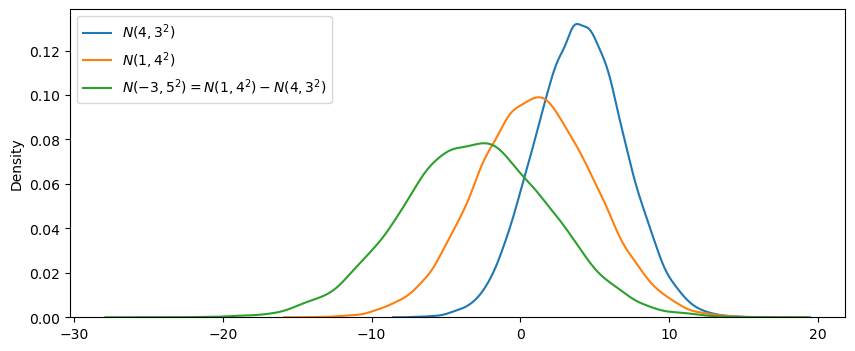

In [24]:
# 가설검정

import seaborn as sns
from matplotlib import pyplot as plt

np.random.seed(123)

n1 = np.random.normal(4, 3, 30000) # (평균, 표준편차, 샘플 수)
n2 = np.random.normal(1, 4, 30000)
n_diff = n2 - n1

plt.figure(figsize=(10, 4))
sns.distplot(n1, hist=False, label="$N(4,3^2)$")
sns.distplot(n2, hist=False, label="$N(1,4^2)$")
sns.distplot(n_diff, hist=False, label="$N(-3,5^2) = N(1,4^2) - N(4,3^2)$")
plt.legend()

In [38]:
diff_mu = short_email.mean() - no_email.mean()
diff_se = np.sqrt(no_email.sem()**2 + short_email.sem()**2)

ci = (diff_mu - 1.96 * diff_se, diff_mu + 1.96 * diff_se)
ci = (float(ci[0]), float(ci[1]))
print(f"95% CI for the difference (short_email - no_email): \n {ci}")


95% CI for the difference (short_email - no_email): 
 (0.010239808474398426, 0.15465380854687816)


In [39]:
# 신뢰구간 이동
diff_mu_shifted = short_email.mean() - no_email.mean() - 0.01
diff_se = np.sqrt(no_email.sem()**2 + short_email.sem()**2)

ci = (diff_mu_shifted - 1.96 * diff_se, diff_mu_shifted + 1.96 * diff_se)
ci = (float(ci[0]), float(ci[1]))
print(f"95% CI 1% difference (short_email - no_email) : \n {ci}")

95% CI 1% difference (short_email - no_email) : 
 (0.00023980847439843134, 0.14465380854687815)


In [40]:
# 검정통계량

t_stat = (diff_mu - 0) / diff_se
t_stat = float(t_stat)
t_stat

2.237951231871536

In [ ]:
# p-value
print("p-value:", (1-stats.norm.cdf(t_stat))*2) # two sided test


p-value: 0.025224235562152142


In [45]:
# 검정력
print(stats.norm.cdf(0.84))

0.7995458067395503


In [47]:
# 표본 크기 계산
print(np.ceil(16*(no_email.std()/0.08)**2))

103.0


In [48]:
data.groupby(["cross_sell_email"]).size() # 그룹 별 표본 크기

cross_sell_email
long        109
no_email     94
short       120
dtype: int64

### CH3

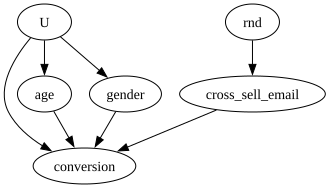

In [ ]:
# p. 104

import graphviz as gr

g_cross_sell = gr.Digraph()

g_cross_sell.edge("U", "conversion")
g_cross_sell.edge("U", "age")
g_cross_sell.edge("U", "gender")

g_cross_sell.edge("rnd", "cross_sell_email")
g_cross_sell.edge("cross_sell_email", "conversion")
g_cross_sell.edge("age", "conversion")
g_cross_sell.edge("gender", "conversion")

g_cross_sell

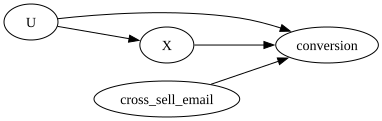

In [3]:
g_cross_sell = gr.Digraph(graph_attr={"rankdir": "LR"}) # 그래프가 왼쪽에서 오른쪽으로 화살표가 향하도록

g_cross_sell.edge("U", "conversion")
g_cross_sell.edge("U", "X")

g_cross_sell.edge("cross_sell_email", "conversion")
g_cross_sell.edge("X", "conversion")

g_cross_sell

In [20]:
# networkx를 이용한 DAG 시각화
import networkx as nx

model = nx.DiGraph([
    ("C", "A"),
    ("C", "B"),
    ("D", "A"),
    ("B", "E"),
    ("F", "E"),
    ("A", "G")
])

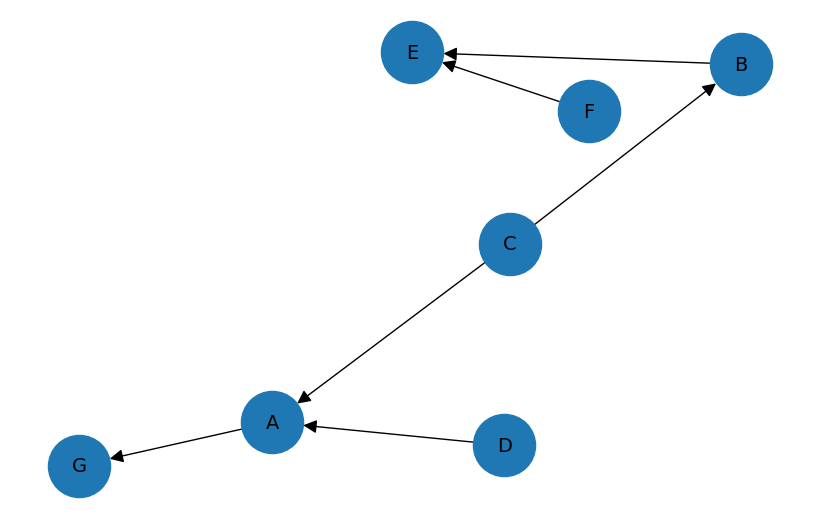

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

nx.draw(
    model,
    with_labels=True,
    node_size=2000,
    font_size=14,
    arrowsize=20
)

plt.show()

In [ ]:
# d_separated -> is_d_sepatator, {} -> set()

# 충돌부 (collider)

print("Are D and C dependent?")
print(not(nx.is_d_separator(model, {"D"}, {"C"}, set()))) # D와 C는 독립인가? (X, Y, Z) X와 Y가 Z에 대해 조건부 독립인지 확인

print("Are D and C dependent given A?")
print(not(nx.is_d_separator(model, {"D"}, {"C"}, {"A"}))) 

print("Are D and C dependent given G?")
print(not(nx.is_d_separator(model, {"D"}, {"C"}, {"G"}))) 


Are D and C dependent?
False
Are D and C dependent given A?
True
Are D and C dependent given G?
True


In [ ]:
# 사슬(chain)

print("Are G and D dependent?")
print(not(nx.is_d_separator(model, {"G"}, {"D"}, set())))

print("Are G and D dependent given A?")
print(not(nx.is_d_separator(model, {"G"}, {"D"}, {"A"})))

Are G and D dependent?
True
Are G and D dependent given A?
False


In [ ]:
# 분기(fork)

print("Are A and B dependent?")
print(not(nx.is_d_separator(model, {"A"}, {"B"}, set())))

print("Are A and B dependent given C?")
print(not(nx.is_d_separator(model, {"A"}, {"B"}, {"C"})))

Are A and B dependent?
True
Are A and B dependent given C?
False


In [ ]:
# example

print("Are G and F dependent?")
print(not(nx.is_d_separator(model, {"G"}, {"F"}, set())))

print("Are G and F dependent given E?")
print(not(nx.is_d_separator(model, {"G"}, {"F"}, {"E"})))

Are G and F dependent?
False
Are G and F dependent given E?
True


In [ ]:
# 식별 재해석
# p. 119

# fork
consultancy_model_severed = nx.DiGraph([
    ("profits_prev_6m", "profits_next_6m"),
    ("profits_prev_6m", "consultancy"),
    # ("consultancy", "profits_next_6m") # 인과관계 제거
])

not(nx.is_d_separator(consultancy_model_severed, {"consultancy"}, {"profits_next_6m"}, set())) # consultancy와 profits_next_6m은 독립인가?

True

In [34]:
df = pd.DataFrame(dict(
    profits_prev_6m = [1, 1, 1, 5, 5, 5],
    consultancy = [0, 0, 1, 0, 1, 1],
    profits_next_6m = [1, 1.1, 1.2, 5.5, 5.7, 5.7]
))

df

,profits_prev_6m,consultancy,profits_next_6m
0,1,0,1.0
1,1,0,1.1
2,1,1,1.2
3,5,0,5.5
4,5,1,5.7
5,5,1,5.7


In [36]:
print((df.query("consultancy==1")["profits_next_6m"].mean() - df.query("consultancy==0")["profits_next_6m"].mean()))

1.666666666666667


In [38]:
avg_df = (df
          .groupby(["consultancy", "profits_prev_6m"])
          ["profits_next_6m"]
          .mean())

avg_df.loc[1] - avg_df.loc[0]

profits_prev_6m
1    0.15
5    0.20
Name: profits_next_6m, dtype: float64

In [40]:
# 선택편향
# p.128

nps_model = nx.DiGraph([
    ("RND", "New Feature"),
    # ("New Featire", "Customer Satisfaction"),
    ("Customer Satisfaction", "NPS"), 
    ("Customer Satisfaction", "Response"),
    ("New Feature", "Response")
])

not(nx.is_d_separator(nps_model, {"NPS"}, {"New Feature"}, {"Response"}))

True

In [4]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.
